In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler

# 1. Spark Oturumunu Delta Paketleriyle Birlikte Başlat
spark = SparkSession.builder \
    .appName("ML_KMeans_Clustering") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.1.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

print("Adım 1: Feature Store'dan hazır veriler okunması")
# 2. Takım arkadaşlarının hazırladığı Delta formatındaki temiz veriyi oku
feature_df = spark.read.format("delta").load("/tmp/delta/features/review_features_with_sentiment")

print("Adım 2: Veriler makine öğrenmesi formatına (Vector) dönüştürülmesi")
# 3. Özellikleri (Features) tek bir vektörde topla
assembler = VectorAssembler(
    inputCols=[
        'sentiment_score', 'star_rating', 'event_hour', 
        'day_of_week', 'is_weekend', 'user_review_count',
        'product_review_count', 'day_review_count', 'hour_review_count'
    ],
    outputCol="features"
)
data = assembler.transform(feature_df)

print("Adım 3: K-Means Modeli eğitilmesi")
# 4. K-Means Algoritmasını Kur ve Eğit (3 farklı müşteri profili)
kmeans = KMeans(k=3, seed=42)
model = kmeans.fit(data)
predictions = model.transform(data)

print("-" * 50)
print("MODEL BAŞARIYLA EĞİTİLDİ =,) KÜMELEME SONUÇLARI:")
print("-" * 50)

# 5. Kümelerin Dağılımını Analiz Et
print("Kümelerin (0, 1, 2) Duygu Etiketlerine Göre Dağılımı:")
predictions.groupBy("sentiment_label", "prediction").count().orderBy("prediction", "sentiment_label").show()

Adım 1: Feature Store'dan hazır veriler okunması
Adım 2: Veriler makine öğrenmesi formatına (Vector) dönüştürülmesi
Adım 3: K-Means Modeli eğitilmesi
--------------------------------------------------
MODEL BAŞARIYLA EĞİTİLDİ =,) KÜMELEME SONUÇLARI:
--------------------------------------------------
Kümelerin (0, 1, 2) Duygu Etiketlerine Göre Dağılımı:
+---------------+----------+-----+
|sentiment_label|prediction|count|
+---------------+----------+-----+
|       Negative|         0|    6|
|        Neutral|         0|   59|
|       Positive|         0|   43|
|       Negative|         1|   11|
|        Neutral|         1|  201|
|       Positive|         1|  140|
|        Neutral|         2|   19|
|       Positive|         2|   21|
+---------------+----------+-----+



BİLİMSEL DENEY METRİKLERİ HESAPLANIYOR...

K-Means (k=3) Silhouette Skoru: 0.9539
(Not: Bu skor -1 ile 1 arasındadır. 1'e ne kadar yakınsa kümeler o kadar iyi ayrışmış demektir.)


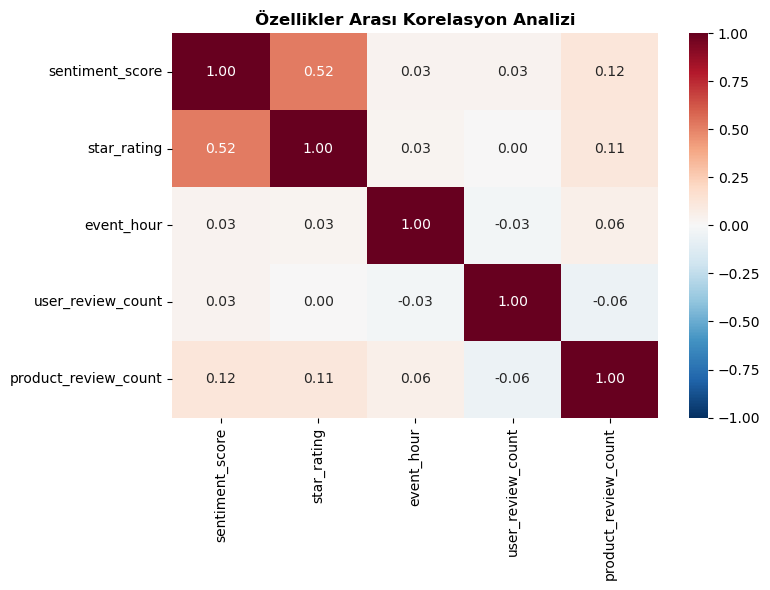

/tmp/ipykernel_7670/2601473264.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Önem Derecesi', y='Özellik', palette='viridis')


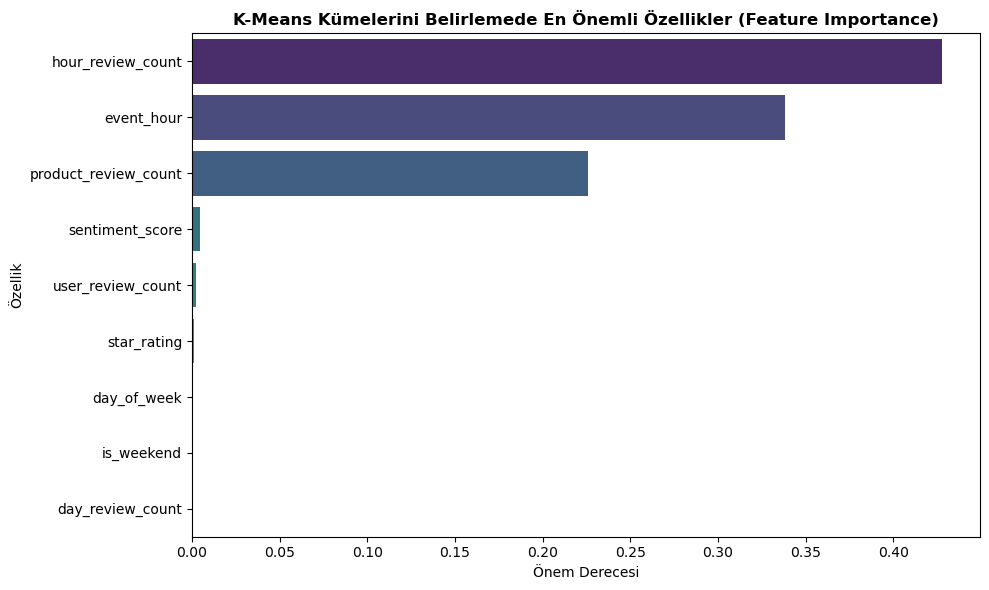

In [2]:
# ============================================================================
# İREM'İN İSTEDİĞİ DENEY VE ANALİZ METRİKLERİ
# ============================================================================
print("BİLİMSEL DENEY METRİKLERİ HESAPLANIYOR...")

from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.classification import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------------------------------------
# 1. MODEL BAŞARISI (SILHOUETTE SKORU)
# ---------------------------------------------------------
# Kümelemenin kalitesini ölçüyoruz 
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(predictions)
print(f"\nK-Means (k=3) Silhouette Skoru: {silhouette:.4f}")
print("(Not: Bu skor -1 ile 1 arasındadır. 1'e ne kadar yakınsa kümeler o kadar iyi ayrışmış demektir.)")

# ---------------------------------------------------------
# 2. KORELASYON ANALİZİ GRAFİĞİ
# ---------------------------------------------------------
# print("\nÖzellikler Arası Korelasyon Matrisi Çiziliyor...")

# Sayısal özellikleri direkt Spark ana tablosundan (predictions) seçip Pandas'a çevirelim
features_for_corr = ['sentiment_score', 'star_rating', 'event_hour', 'user_review_count', 'product_review_count']

# Sadece bu 5 kolonu çekip kendi aralarındaki korelasyonu (ilişkiyi) hesaplıyoruz
corr_df = predictions.select(*features_for_corr).toPandas().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f")
plt.title("Özellikler Arası Korelasyon Analizi", fontweight='bold')
plt.tight_layout()
plt.show()
# ---------------------------------------------------------
# 3. FEATURE IMPORTANCE (ÖZELLİK ÖNEMİ) 
# ---------------------------------------------------------
#print("\nK-Means Kümelerini Açıklayan Özelliklerin Önemi (Random Forest ile) Çıkarılıyor...")

# ÇÖZÜM BURADA: predictionCol="rf_prediction" ekledik ki K-Means'in kolonuyla isimleri çakışmasın!
rf = RandomForestClassifier(labelCol="prediction", featuresCol="features", predictionCol="rf_prediction", numTrees=20, seed=42)
rf_model = rf.fit(predictions)

# Özellik isimleri ve önem derecelerini eşleştirelim
feature_names = [
    'sentiment_score', 'star_rating', 'event_hour', 
    'day_of_week', 'is_weekend', 'user_review_count',
    'product_review_count', 'day_review_count', 'hour_review_count'
]
importances = rf_model.featureImportances.toArray()

# Görselleştirme için Pandas DataFrame yapalım
importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem Derecesi': importances})
importance_df = importance_df.sort_values(by='Önem Derecesi', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Önem Derecesi', y='Özellik', palette='viridis')
plt.title("K-Means Kümelerini Belirlemede En Önemli Özellikler (Feature Importance)", fontweight='bold')
plt.tight_layout()
plt.show()

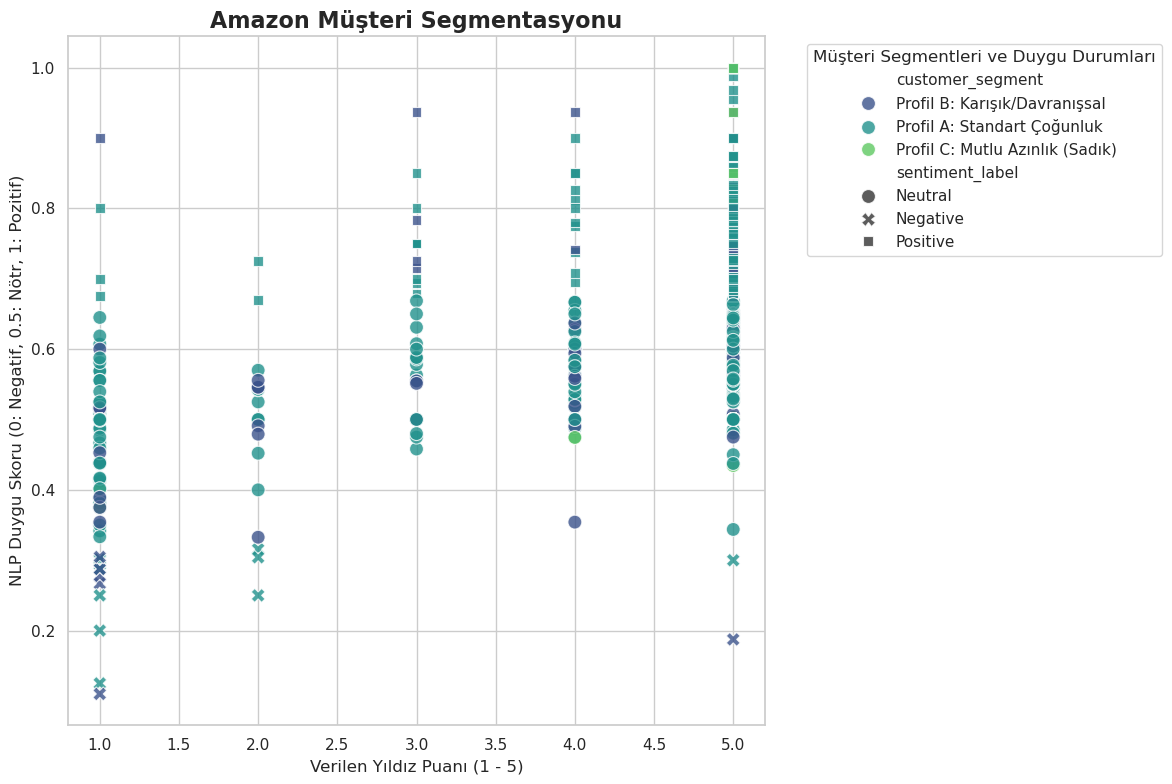

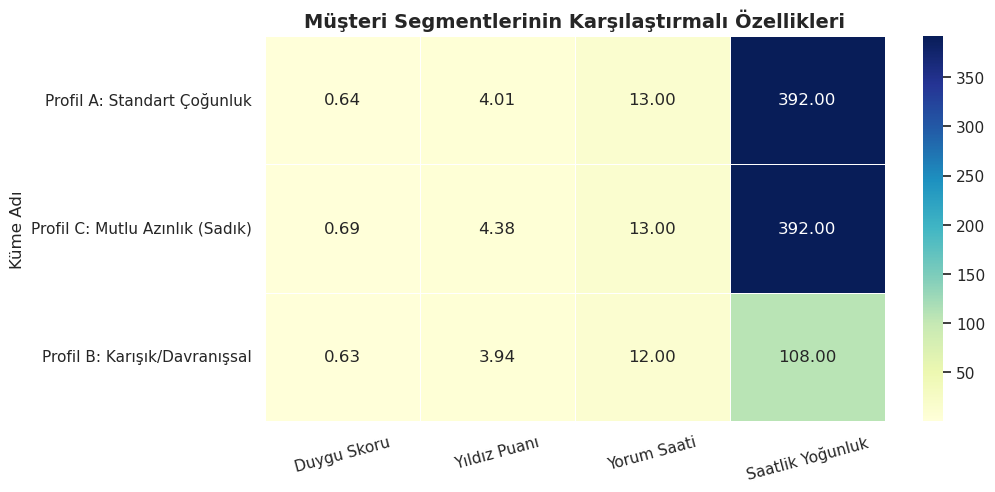

In [4]:
# ============================================================================
# ML_Experiments.ipynb - GÖRSELLEŞTİRME VE ANALİZ HÜCRESİ
# ============================================================================
# Adım 6: Veriler görselleştirme
# 1. PySpark DataFrame'ini Pandas'a çevirelim (500 veri olduğu için çok hızlıdır)
predictions_pd = predictions.select(
    'star_rating', 'sentiment_score', 'sentiment_label', 'prediction'
).toPandas()

# 2. Küme numaralarını (0,1,2) daha anlaşılır isimlerle değiştirelim
# (Bir önceki analizimizde bulduğumuz profillere göre)
cluster_map = {
    1: "Profil A: Standart Çoğunluk",
    0: "Profil B: Karışık/Davranışsal",
    2: "Profil C: Mutlu Azınlık (Sadık)"
}
predictions_pd['customer_segment'] = predictions_pd['prediction'].map(cluster_map)

# ============================================================================
# GÖRSEL 1: KÜMELERİN DAĞILIMI (Dağılım Grafiği - Scatter Plot)
# ============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik temasını ayarlayalım
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# X ekseni: Yıldız Puanı, Y ekseni: Duygu Skoru, Renkler: Kümeler
scatter = sns.scatterplot(
    data=predictions_pd,
    x='star_rating', 
    y='sentiment_score', 
    hue='customer_segment', # Renklendirme kümeye göre
    style='sentiment_label', # Semboller duygu etiketine göre
    palette='viridis', # Renk paleti
    s=100, # Nokta boyutu
    alpha=0.8 # Şeffaflık
)
plt.title('Amazon Müşteri Segmentasyonu', fontsize=16, fontweight='bold')
plt.xlabel('Verilen Yıldız Puanı (1 - 5)', fontsize=12)
plt.ylabel('NLP Duygu Skoru (0: Negatif, 0.5: Nötr, 1: Pozitif)', fontsize=12)

plt.legend(title='Müşteri Segmentleri ve Duygu Durumları', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# ============================================================================
# GÖRSEL 2: KÜMELERİN ORTALAMA ÖZELLİKLERİ (Isı Haritası - DÜZELTİLMİŞ)
# ============================================================================
from pyspark.sql.functions import avg

# Sütunların kaymamasını garanti altına almak için isimleriyle tek tek çekiyoruz
# Isı haritasına Feature Importance'a göre en önemli özelliklerden olan saat ve ürün popülerliği sütunlarını da ekledik
cluster_features = predictions.groupBy("prediction").agg(
    avg("sentiment_score").alias("Duygu Skoru"),
    avg("star_rating").alias("Yıldız Puanı"),
    avg("event_hour").alias("Yorum Saati"),
    avg("hour_review_count").alias("Saatlik Yoğunluk")
).toPandas()

# Profil isimlerini ekleyelim
cluster_features['Küme Adı'] = cluster_features['prediction'].map(cluster_map)
cluster_features = cluster_features.set_index('Küme Adı').drop('prediction', axis=1)

# Isı haritasını çizelim
plt.figure(figsize=(10, 5))
import seaborn as sns
import matplotlib.pyplot as plt

# Koyu renkler yüksek puanları, açık renkler düşük puanları gösterecek
sns.heatmap(cluster_features, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Müşteri Segmentlerinin Karşılaştırmalı Özellikleri', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.show()

In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from pyspark.sql import SparkSession

# DELTA AYARLARI EKLENMİŞ SPARK OTURUMU
spark = SparkSession.builder \
    .appName("SentimentModelTraining") \
    .config("spark.driver.memory", "1536m") \
    .config("spark.executor.memory", "1536m") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.1.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

# 1. Gold veriyi oku
gold_path = "/home/jovyan/data/gold_sentiment_analysis"
df_spark = spark.read.format("delta").load(gold_path)

# 2. Gereksiz sütunları atalım ve Pandas'a çevirelim
features_to_use = [
    "star_rating", "event_hour", "day_of_week", "is_weekend",
    "user_review_count", "product_review_count", "day_review_count", 
    "hour_review_count", "sentiment_label"
]

# Pandas'a çevir
df_pandas = df_spark.select(features_to_use).toPandas()

# Spark ile işimiz bitti, RAM'i tamamen LightGBM'e bırakmak için Spark'ı kapatalım
spark.stop() 

# ---------------------------------------------------------
# LIGHTGBM MODEL EĞİTİMİ KISMI
# ---------------------------------------------------------

# Hedef değişkeni sayısal hale getir
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df_pandas['target'] = df_pandas['sentiment_label'].map(label_map)

# Feature (X) ve Target (y) ayrımı
X = df_pandas.drop(['sentiment_label', 'target'], axis=1)
y = df_pandas['target']

# Eğitim ve Test setlerine ayır (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LightGBM veri setlerini oluştur
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Model parametreleri
params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

# Modeli eğit
print("Model eğitimi başlıyor...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# Tahmin yap
y_pred_prob = model.predict(X_test)
y_pred = [list(x).index(max(x)) for x in y_pred_prob]

# Sonuçları yazdır
print("\n=== MODEL BAŞARI RAPORU ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))

Model eğitimi başlıyor...
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	training's multi_logloss: 0.490435	valid_1's multi_logloss: 0.506815

=== MODEL BAŞARI RAPORU ===
Accuracy Score: 0.7174

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.91      0.95      2772
     Neutral       0.71      0.63      0.67      4351
    Positive       0.52      0.66      0.58      2729

    accuracy                           0.72      9852
   macro avg       0.74      0.73      0.73      9852
weighted avg       0.74      0.72      0.72      9852



/tmp/ipykernel_2511/2971437985.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


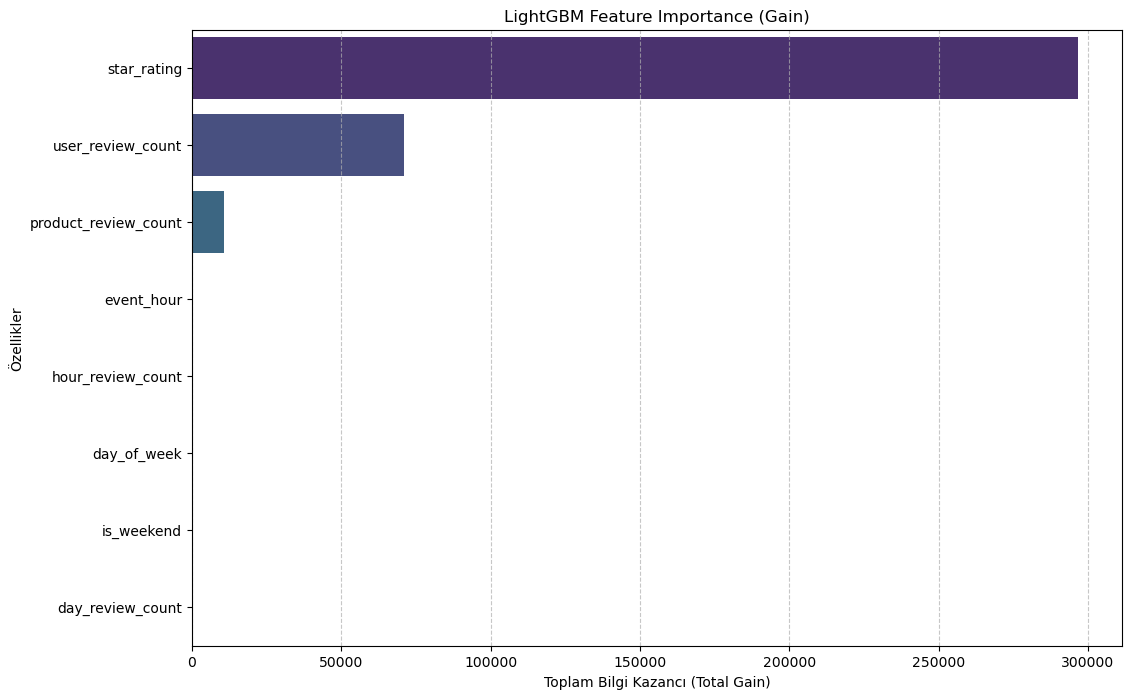


=== ÖZELLİK ÖNEM SIRALAMASI ===
                Feature     Importance
0           star_rating  296616.094247
4     user_review_count   70922.549803
5  product_review_count   10857.697502
1            event_hour     366.152977
7     hour_review_count      54.825522
2           day_of_week       0.000000
3            is_weekend       0.000000
6      day_review_count       0.000000


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Özellik Önemlerini Al (Gain tipinde)
importance_type = 'gain'
feature_importances = model.feature_importance(importance_type=importance_type)
feature_names = X.columns

# 2. DataFrame Oluştur
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 3. Görselleştirme
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title(f'LightGBM Feature Importance ({importance_type.capitalize()})')
plt.xlabel('Toplam Bilgi Kazancı (Total Gain)')
plt.ylabel('Özellikler')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Sayısal Rapor
print("\n=== ÖZELLİK ÖNEM SIRALAMASI ===")
print(importance_df)